<a href="https://colab.research.google.com/github/zyuneee/portfolio/blob/main/%EC%98%81%EC%83%81%EC%B2%98%EB%A6%AC_%EC%97%B0%EC%82%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib_inline

In [39]:
img = cv2.imread('/content/like_lenna.png')

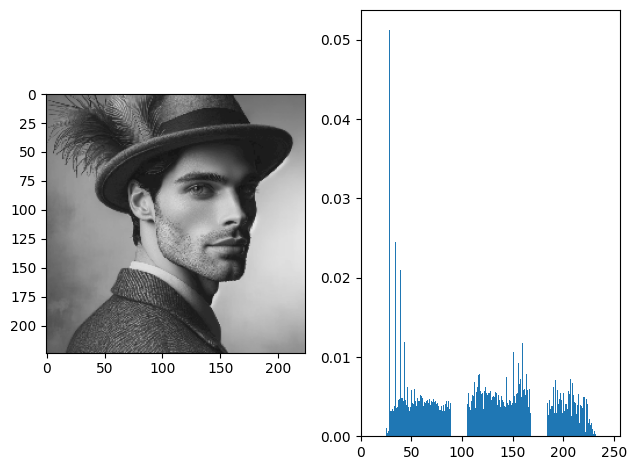

In [16]:
#히스토그램 그리기
hist = np.zeros(256)
img_flat = np.reshape(img, -1)

for i in range(len(img_flat)):
  hist[img_flat[i]]+=1

hist= hist/len(img_flat)

fig= plt.figure()
plt.subplot(121)
plt.imshow(img,cmap='gray')

plt.subplot(122)
plt.bar(np.arange(256),hist)
plt.xlim([0,256])
fig.tight_layout()
plt.show()

In [29]:
gray_img= img = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)

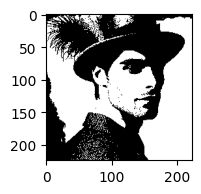

In [31]:
#임계값 구하기  오츄알고리즘
ret6, thr6 = cv2.threshold(gray_img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
fig = plt.figure()
plt.subplot(231)
plt.imshow(thr6,cmap='gray')

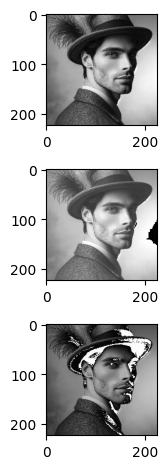

In [36]:
#점연산

a=32

fig=plt.figure()
plt.subplot(311)
plt.imshow(gray_img,cmap='gray')

plt.subplot(312)
plt.imshow(np.clip(img+a,0,255),cmap='gray')

plt.subplot(313)
plt.imshow(np.clip(img-a,0,255),cmap='gray')
fig.tight_layout()

plt.show()

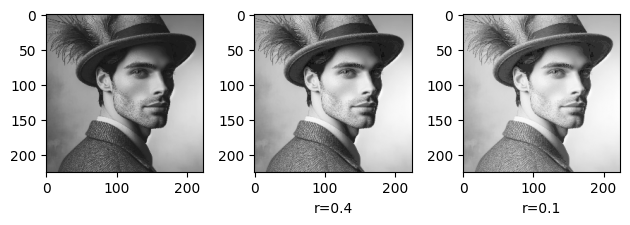

In [45]:
#영역연산 중 비선형 감마 연산

def gamma_operation(img,gamma,L):
  hat_img =gray_img.copy()/float(L)
  return np.clip(L*((hat_img)**gamma),0,L)

fig= plt.figure()
plt.subplot(231)
plt.imshow(img,cmap='gray') #cmap은 이미지가 흑백일때 꼭 써야함, 안그러면 imshow가 색을 입혀 읽음
plt.subplot(232)
plt.imshow(gamma_operation(img,0.4,255),cmap='gray')
plt.xlabel('r=0.4')
plt.subplot(233)
plt.imshow(gamma_operation(img,0.1,255),cmap='gray')
plt.xlabel('r=0.1')

fig.tight_layout()
plt.show()